# Identificazione automatica della lingua

**Obiettivo:** Addestrare un modello di machine learning (NLP) che classifichi correttamente la lingua di ogni testo.

1. Caricamento e ispezione del dataset
2. Preprocessing e pulizia del testo
3. Estrazione di feature con TF-IDF
4. Addestramento di più modelli (Naive Bayes, SVM, Random Forest)
5. Valutazione e confronto delle performance
6. Cross validation
7. Analisi degli errori
8. Test su testi custom
9. Conclusioni e commenti

## 1. Import delle librerie

In [41]:
import io

#librerie standard
import re  #espressioni regolari per la pulizia del testo
import warnings
warnings.filterwarnings('ignore') #sopprimo warning non critici per leggibilità

#data manipulation
import numpy as np
import pandas as pd

#NLP/feature extraction
import nltk
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer  #rappresentazione TF-IDF

#modelli di classificazione
from sklearn.naive_bayes import MultinomialNB #naive bayes (baseline)
from sklearn.svm import LinearSVC  #SVM lineare
from sklearn.ensemble import RandomForestClassifier #random forest

#suddivisione e validazione
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline  #preprocessing+modello

#metriche
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#visualizzazione
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

#risorse nltk per la tokenizzazione
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print("librerie importate correttamente")

librerie importate correttamente


## 2. Caricamento del dataset

In [42]:
#url del dataset
DATASET_URL = (
    "https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Modello%20per%20l'identificazione%20della%20lingua%20dei%20testi%20di%20un%20museo/museo_descrizioni.csv"
)

#caricamento
try:
    df = pd.read_csv(DATASET_URL)
    print(f"dataset caricato")
except Exception as e:
    print(f"url non raggiungibile ({e}).")

print(f"\nDataset: {df.shape[0]} righe x {df.shape[1]} colonne")
print(f"Colonne: {df.columns.tolist()}")
df.head(10)

dataset caricato

Dataset: 294 righe x 2 colonne
Colonne: ['Testo', 'Codice Lingua']


,Testo,Codice Lingua
0,Statua in marmo di un imperatore romano del II...,it
1,Anfora greca con decorazioni a figure nere,it
2,Dipinto rinascimentale raffigurante la Madonna...,it
3,Elmo corinzio in bronzo del VI secolo a.C.,it
4,Manoscritto medievale con miniature dorate,it
5,Scultura lignea gotica di un santo,it
6,Spada vichinga con impugnatura decorata,it
7,Maschera funeraria egizia in oro,it
8,Tavoletta sumera con incisioni cuneiformi,it
9,Vaso cinese della dinastia Ming con smalti blu...,it


## 3. Analisi esplorativa (EDA)

In [43]:
#info generali dataset

print("Info generali")
df.info()

print("\nValori nulli per colonna")
print(df.isnull().sum())

print("\nDistribuzione target")
lang_counts = df['Codice Lingua'].value_counts()
print(lang_counts)

Info generali
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Testo          294 non-null    object
 1   Codice Lingua  294 non-null    object
dtypes: object(2)
memory usage: 4.7+ KB

Valori nulli per colonna
Testo            0
Codice Lingua    0
dtype: int64

Distribuzione target
Codice Lingua
it    98
en    98
de    98
Name: count, dtype: int64


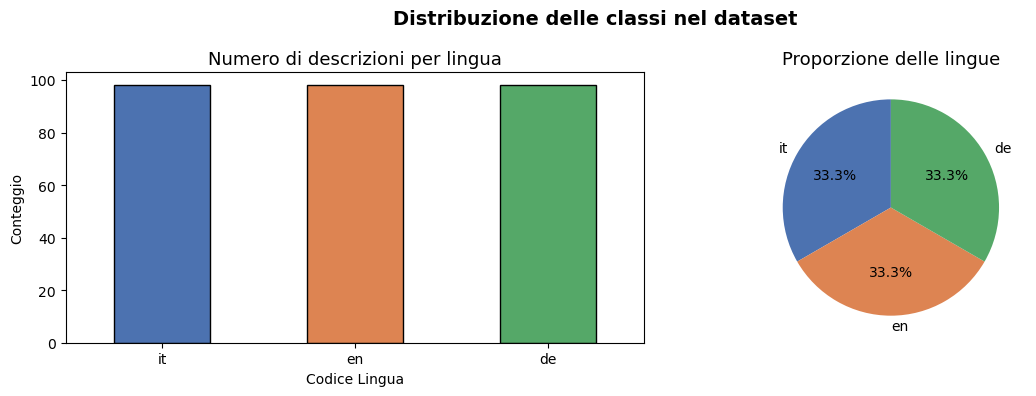

In [44]:
#visualizzazione della distribuzione delle classi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#conteggio esempi per lingua
lang_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black', width=0.5)
axes[0].set_title('Numero di descrizioni per lingua', fontsize=13)
axes[0].set_xlabel('Codice Lingua')
axes[0].set_ylabel('Conteggio')
axes[0].set_xticklabels(lang_counts.index, rotation=0)

#percentuale esempi per lingua
axes[1].pie(lang_counts, labels=lang_counts.index, autopct='%1.1f%%', colors=['#4C72B0', '#DD8452', '#55A868'], startangle=90)
axes[1].set_title('Proporzione delle lingue', fontsize=13)

plt.suptitle('Distribuzione delle classi nel dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#>>>> il dataset è bilanciato

In [45]:
#analisi lunghezza testi
#aggiungo colonne ausiliarie per analizzare la struttura linguistica dei testi
df['lunghezza_caratteri'] = df['Testo'].apply(len)
df['numero_parole']= df['Testo'].apply(lambda t: len(t.split()))

#statistiche per lingua
print("Lunghezza media dei testi (in caratteri) per lingua:")
print(df.groupby('Codice Lingua')['lunghezza_caratteri'].describe().round(1))

print("\nNumero medio di parole per lingua:")
print(df.groupby('Codice Lingua')['numero_parole'].mean().round(2))

Lunghezza media dei testi (in caratteri) per lingua:
               count  mean   std   min   25%   50%   75%   max
Codice Lingua                                                 
de              98.0  46.2  10.5  21.0  39.0  46.0  52.8  77.0
en              98.0  41.8   9.1  15.0  36.0  42.0  47.8  68.0
it              98.0  44.9   7.7  25.0  40.0  45.0  49.0  61.0

Numero medio di parole per lingua:
Codice Lingua
de    5.07
en    6.12
it    6.57
Name: numero_parole, dtype: float64


## 4. Preprocessing del testo

Eseguo una pulizian dei dati leggera ma efficace: rimozione di caratteri speciali e normalizzazione in minuscolo.<br>
Non rimuovo le stopword perché in questo caso (data la natura del task) sono utili: parole come "il", "la", "the", "die" sono segnali discriminanti tra lingue.<br>
Lo stemming è omesso perchè distrugge proprio i suffissi morfologici (utili per il task). Per motivi analoghi non viene implementata la lemmatizzazione

In [46]:
def preprocess_text(text: str) -> str:
    """
    Pulisce e normalizza un testo per la classificazione della lingua

    Operazioni
    - conversione in minuscolo: riduce la variabilità senza perdere informazioni linguistiche
    - rimozione di caratteri numerici: i numeri non sono discriminanti per la lingua
    - rimozione di caratteri speciali (tranne lettere accentate): le lettere accentate (ä, ü, è, é) sono segnali linguistici molto forti, quindi le conservo
    - rimozione di spazi multipli: normalizzazione degli spazi         
    
    Parametri
    - text: str (testo grezzo da processare)
    - Returns: str (testo pulito e normalizzato)
    """


    #conversione in minuscolo
    text = text.lower()

    #rimozione cifre (numeri)
    text = re.sub(r'\d+', '', text)

    #rimozione caratteri speciali e punteggiatura
    #vengono mantenute solo lettere lettere (incluse accentate e umlaut) e spazi
    #\w copre [a-zA-Z0-9_]; uso [^\w\s] per rimuovere punteggiatura ma aggiungo un charset più ampio per i caratteri unicode delle 3 lingue
    text = re.sub(r"[^\w\s\u00C0-\u024F]", ' ', text)

    #rimozione spazi multipli e collasso in un singolo spazio
    text = re.sub(r'\s+', ' ', text).strip()

    return text


#applico il preprocessing a tutti i testi del dataset
df['Testo_Pulito'] = df['Testo'].apply(preprocess_text)

#verifica visiva del preprocessing
print("Confronto testo originale con testo pulito:")
for _, row in df[['Testo', 'Testo_Pulito', 'Codice Lingua']].head(5).iterrows():
    print(f"[{row['Codice Lingua']}] ORIGINALE : {row['Testo']}")
    print(f"   TESTO PULITO: {row['Testo_Pulito']}")
    print()

Confronto testo originale con testo pulito:
[it] ORIGINALE : Statua in marmo di un imperatore romano del II secolo
   TESTO PULITO: statua in marmo di un imperatore romano del ii secolo

[it] ORIGINALE : Anfora greca con decorazioni a figure nere
   TESTO PULITO: anfora greca con decorazioni a figure nere

[it] ORIGINALE : Dipinto rinascimentale raffigurante la Madonna con il bambino
   TESTO PULITO: dipinto rinascimentale raffigurante la madonna con il bambino

[it] ORIGINALE : Elmo corinzio in bronzo del VI secolo a.C.
   TESTO PULITO: elmo corinzio in bronzo del vi secolo a c

[it] ORIGINALE : Manoscritto medievale con miniature dorate
   TESTO PULITO: manoscritto medievale con miniature dorate



## 5. Suddivisione train-test

In [47]:
#estrazione feature (X) e target (y)
X = df['Testo_Pulito']  #testo preprocessato
y = df['Codice Lingua'] #lingua da predire

#suddivisione train (0.8) e test (0.2)
#stratify=y per garantire che la proporzione delle lingue sia uguale nei due set
#random_state per riproducibilità
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=8734219
)

print(f"Campioni totali: {len(X)}")
print(f"Campioni training: {len(X_train)} ({len(X_train)/len(X):.0%})")
print(f"Campioni test: {len(X_test)}  ({len(X_test)/len(X):.0%})")
print("\nDistribuzione classi training set:")
print(y_train.value_counts())
print("\nDistribuzione classi test set:")
print(y_test.value_counts())

Campioni totali: 294
Campioni training: 235 (80%)
Campioni test: 59  (20%)

Distribuzione classi training set:
Codice Lingua
it    79
en    78
de    78
Name: count, dtype: int64

Distribuzione classi test set:
Codice Lingua
de    20
en    20
it    19
Name: count, dtype: int64


## 6. Feature extraction: TF-IDF con n-grammi di caratteri

Uso il tf-idf a livello di caratteri (analyzer='char_wb') con n-grammi di lunghezza 2–4.
- si riescono a catturare pattern ortografici tipici di ogni lingua
- si genera indipendenza dal vocabolario e risulta più robusta su testi con parole rare e/o con nomi propri
- è una strategia efficace specialmente nel caso di testi molto brevi

In [48]:
tfidf = TfidfVectorizer(
    analyzer='char_wb', #n-grammi di caratteri con padding dei bordi di parola
    ngram_range=(2, 4), #considero sequenze di 2, 3 e 4 caratteri
    max_features=5000, #limito le feature (in questo contesto vengono raggiunte performance ottime ma in generale è usato per ridurre memoria e limitare il rischio di overfitting)
    sublinear_tf=True #applica log(tf)+1 invece di tf grezzo (riduce l'impatto di parole molto frequenti)
)

#fit sul training set e transform su train e test. fit solo sul training set per evitare data leakage
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Dimensioni matrice tf-idf training: {X_train_tfidf.shape}")
print(f"Dimensioni matrice tf-idf test: {X_test_tfidf.shape}")
print(f"\nEsempio di n-grammi estratti:")
print(tfidf.get_feature_names_out()[:20])

Dimensioni matrice tf-idf training: (235, 5000)
Dimensioni matrice tf-idf test: (59, 5000)

Esempio di n-grammi estratti:
[' a' ' a ' ' ac' ' acc' ' af' ' aff' ' afr' ' ag' ' age' ' al' ' alf'
 ' alp' ' alt' ' am' ' ama' ' amb' ' ame' ' amp' ' an' ' an ']


## 7. Addestramento dei modelli

Confronto tre algoritmi classici per la classificazione testuale:

| Modello | Pro | Contro |
|---------|-----|--------|
| **Naive Bayes** | veloce, baseline solida per NLP | assunzione di indipendenza tra feature |
| **LinearSVC** | eccellente su spazi ad alta dimensionalità | meno interpretabile |
| **Random Forest** | robusto e gestisce non-linearità | più lento e può soffrire su feature sparse |

In [49]:
def train_and_evaluate(name: str, model, X_tr, y_tr, X_te, y_te, class_labels):
    """
    Addestra un modello, calcola le metriche di valutazione e restituisce un dizionario con i risultati

    Parametri
    name: str (nome del modello)
    model: sklearn estimator (modello non ancora addestrato)
    X_tr, y_tr: dati di training
    X_te, y_te: dati di test
    class_labels: lista etichette delle classi target

    Returns: dict (con metriche e oggetto modello addestrato)
    """


    #addestramento
    model.fit(X_tr, y_tr)

    #predizione sul test set
    y_pred = model.predict(X_te)

    #calcolo metriche
    acc= accuracy_score(y_te, y_pred)
    prec= precision_score(y_te, y_pred, average='weighted')
    rec = recall_score(y_te, y_pred, average='weighted')
    f1=f1_score(y_te, y_pred, average='weighted')

    print(f"{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"\nReport dettagliato per classe:")
    print(classification_report(y_te, y_pred, target_names=class_labels))

    return {
        'name':      name,
        'model':     model,
        'y_pred':    y_pred,
        'accuracy':  acc,
        'precision': prec,
        'recall':    rec,
        'f1':        f1
    }


#etichette delle classi per report
CLASSES = sorted(y.unique().tolist())

#naive bayes multinomiale
nb_results = train_and_evaluate(
    "Naive Bayes Multinomiale",
    MultinomialNB(alpha=0.1), #leggero smoothing di laplace
    X_train_tfidf, y_train, X_test_tfidf, y_test, CLASSES
)

#support vector machine (lineare)
svm_results = train_and_evaluate(
    "LinearSVC (SVM lineare)",
    LinearSVC(C=1.0, #parametro di regolarizzazione di default
    max_iter=2000, #aumento le iterazioni massime per garantire convergenza
    random_state=8734219),
    X_train_tfidf, y_train, X_test_tfidf, y_test, CLASSES
)

#random forest
rf_results = train_and_evaluate(
    "Random Forest",
    RandomForestClassifier(n_estimators=200, #200 alberi per una stima stabile
    random_state=8734219, 
    n_jobs=-1), #usa tutti i core
    X_train_tfidf, y_train, X_test_tfidf, y_test, CLASSES
)

Naive Bayes Multinomiale
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Report dettagliato per classe:
              precision    recall  f1-score   support

          de       1.00      1.00      1.00        20
          en       1.00      1.00      1.00        20
          it       1.00      1.00      1.00        19

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59

LinearSVC (SVM lineare)
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Report dettagliato per classe:
              precision    recall  f1-score   support

          de       1.00      1.00      1.00        20
          en       1.00      1.00      1.00        20
          it       1.00      1.00      1.00        19

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00   

## 8. Confronto tra metriche e visualizzazioni

In [50]:
#tabella per confronto tra metriche
all_results = [nb_results, svm_results, rf_results]

comparison_df = pd.DataFrame([
    {
        'Modello': r['name'],
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1']
    }
    for r in all_results
]).set_index('Modello')

print("\nTabella comparativa delle metriche (su test set):")
print(comparison_df.round(4).to_string())


Tabella comparativa delle metriche (su test set):
                          Accuracy  Precision  Recall  F1-Score
Modello                                                        
Naive Bayes Multinomiale       1.0        1.0     1.0       1.0
LinearSVC (SVM lineare)        1.0        1.0     1.0       1.0
Random Forest                  1.0        1.0     1.0       1.0


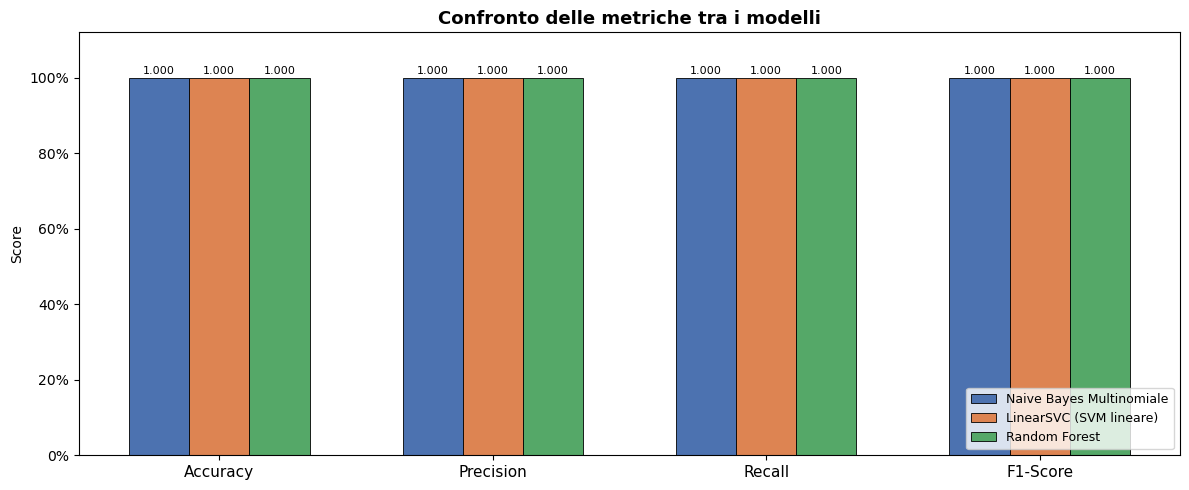

In [51]:
#grafico a barre raggruppate per confronto
fig, ax = plt.subplots(figsize=(12, 5))

metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors   = ['#4C72B0', '#DD8452', '#55A868']
n_models = len(all_results)
x        = np.arange(len(metrics))  #posizioni delle barre
bar_w    = 0.22

for i, (res, color) in enumerate(zip(all_results, colors)):
    vals = [res['accuracy'], res['precision'], res['recall'], res['f1']]
    bars = ax.bar(x + i * bar_w, vals, width=bar_w, label=res['name'],
                  color=color, edgecolor='black', linewidth=0.6)
    #etichetta numerica sopra ogni barra
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + bar_w)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Confronto delle metriche tra i modelli', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

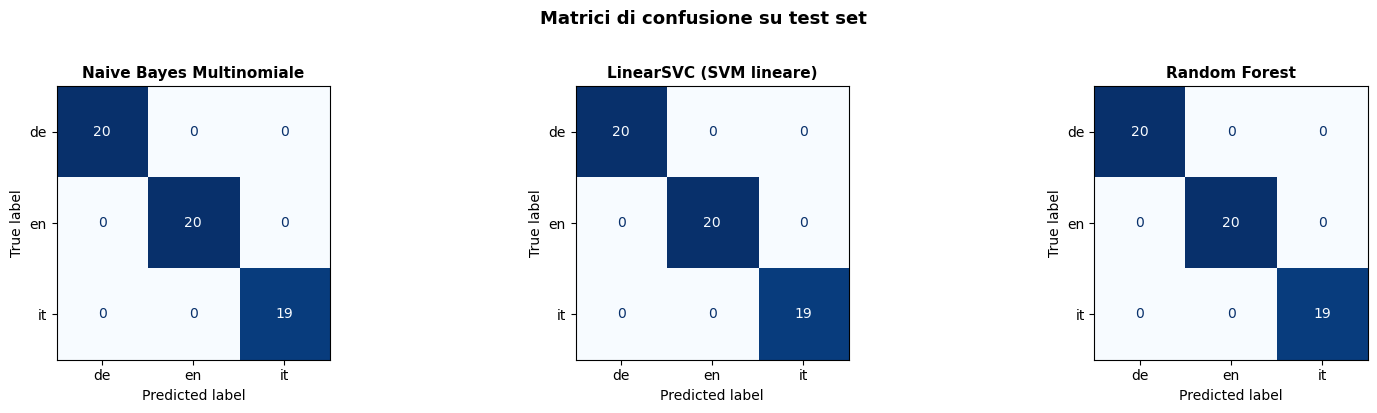

In [52]:
#matrici di confusione

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, res in zip(axes, all_results):
    cm = confusion_matrix(y_test, res['y_pred'], labels=CLASSES)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['name'], fontsize=11, fontweight='bold')

plt.suptitle('Matrici di confusione su test set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#>>>> Interpretazione: performance perfette e off-diagonal a 0 (in altre prove omesse le performance erano stabili, con al più 1-2 errori di classificazione)

## 9. K-fold cross-validation

La cross-validation a k fold (in questo caso k=5) fornisce una stima più robusta delle performance rispetto a un singolo split train/test, riducendo così la varianza della valutazione

In [53]:
#configurazioni cross-validation
#>>>> uso pipeline per incapsulare tf-idf e modello in un unico oggetto: questo garantisce che la trasformazione 
#        tf-idf venga ricalcolata ad ogni fold evitando così il data leakage tra fold di validazione e fold di addestramento

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=980859) #mantiene la proporzione delle classi in ogni fold

#definisco la stessa configurazione tf-idf usata precedentemente
tfidf_cv = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                            max_features=5000, sublinear_tf=True)

pipelines = {
    'Naive Bayes': Pipeline([
        ('tfidf', tfidf_cv),
        ('clf',   MultinomialNB(alpha=0.1))
    ]),
    'LinearSVC': Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                                  max_features=5000, sublinear_tf=True)),
        ('clf',   LinearSVC(C=1.0, max_iter=2000, random_state=980859))
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                                  max_features=5000, sublinear_tf=True)),
        ('clf',   RandomForestClassifier(n_estimators=200, random_state=980859, n_jobs=-1))
    ])
}

#eseguo la cv per ogni pipeline
cv_results = {}
print("Cross-validation (5-fold stratified) — F1 Weighted:")

for model_name, pipeline in pipelines.items():
    scores = cross_val_score(
        pipeline, X, y,
        cv=skf,
        scoring='f1_weighted',
        n_jobs=-1
    )
    cv_results[model_name] = scores
    print(f"{model_name:<20} | Media: {scores.mean():.4f} | Std: {scores.std():.4f} | Fold: {np.round(scores, 4)}")

Cross-validation (5-fold stratified) — F1 Weighted:
Naive Bayes          | Media: 0.9966 | Std: 0.0068 | Fold: [0.9831 1.     1.     1.     1.    ]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/

LinearSVC            | Media: 0.9966 | Std: 0.0068 | Fold: [0.9831 1.     1.     1.     1.    ]
Random Forest        | Media: 0.9898 | Std: 0.0083 | Fold: [0.983  0.9831 1.     0.9831 1.    ]


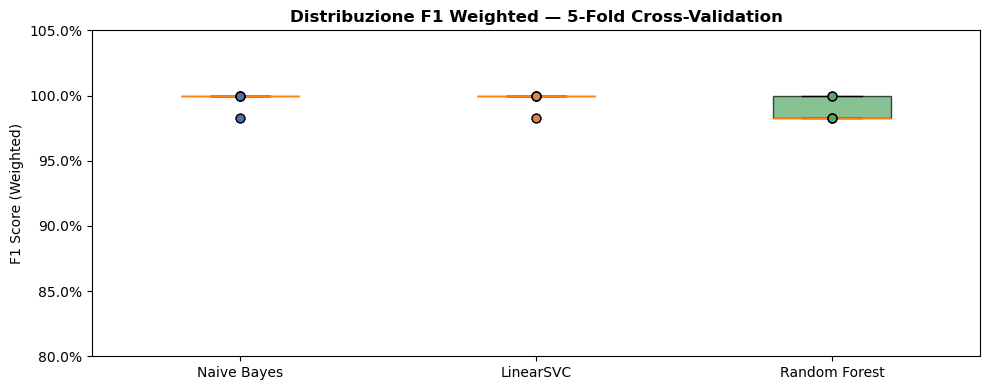

In [54]:
#visualizzazione distribuzione cv scores
fig, ax = plt.subplots(figsize=(10, 4))

cv_data   = [cv_results[m] for m in pipelines.keys()]
cv_labels = list(pipelines.keys())
colors_cv = ['#4C72B0', '#DD8452', '#55A868']

bp = ax.boxplot(cv_data, labels=cv_labels, patch_artist=True, widths=0.4)
for patch, color in zip(bp['boxes'], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

#sovrapposizione punti individuali per trasparenza
for i, (data, color) in enumerate(zip(cv_data, colors_cv), start=1):
    ax.scatter([i] * len(data), data, color=color, s=40, zorder=3, edgecolor='black')

ax.set_title('Distribuzione F1 Weighted — 5-Fold Cross-Validation', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score (Weighted)')
ax.set_ylim(0.8, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

## 10. Analisi degli errori

Inserico lo script completo ma in questo caso non è utile dato che le performance anche in cross-validation sono eccellenti.<br>
In generale, a questo punto si dovrebbero identificare i campioni classificati in modo errato dal modello migliore per capire dove fallisce.

In [55]:
#identifico il modello migliore per F1
best_result = max(all_results, key=lambda r: r['f1'])
print(f"Modello migliore (per F1-Score): {best_result['name']} | F1 = {best_result['f1']:.4f}")

#ricostruisco il dataframe del test set con le predizioni del modello migliore
test_df = X_test.reset_index(drop=True).to_frame()
test_df['lingua_reale']= y_test.reset_index(drop=True)
test_df['lingua_predetta']= best_result['y_pred']

#filtro solo gli errori
errori = test_df[test_df['lingua_reale'] != test_df['lingua_predetta']]

if errori.empty:
    print("\nIl modello migliore non ha commesso errori sul test set")
else:
    print(f"\nNumero di errori: {len(errori)} su {len(test_df)} campioni")
    print("\nDettaglio degli errori:")
    for _, row in errori.iterrows():
        print(f"Testo: '{row['Testo_Pulito'][:70]}...'")
        print(f"Reale: {row['lingua_reale']} | Predetto: {row['lingua_predetta']}")
        print()

Modello migliore (per F1-Score): Naive Bayes Multinomiale | F1 = 1.0000

Il modello migliore non ha commesso errori sul test set


## 11. Test su testi custom

Simulazione del sistema in produzione: l'utente fornisce un testo e il modello identifica la lingua.<br>
In questa sezione costruisco la pipeline del modello migliore per produzione usando un TF-IDF fittato sull'intero dataset (non solo sul training) dato che in questa fase la valutazione avverrà su esempi completamente nuovi e custom

In [56]:
#pipeline finale per la produzione


#scelgo il modello migliore tra quelli testati
best_model_class = {
    'Naive Bayes Multinomiale': MultinomialNB(alpha=0.1),
    'LinearSVC (SVM lineare)': LinearSVC(C=1.0, max_iter=2000, random_state=980859), #stessi seed della cv e stesse configurazioni
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=980859, n_jobs=-1)
}[best_result['name']]

production_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                               max_features=5000, sublinear_tf=True)),
    ('clf',   best_model_class)
])

#riaddestro sull'intero dataset per massimizzare le informazioni disponibili
production_pipeline.fit(X, y)
print(f"Pipeline di produzione addestrata con: {best_result['name']}")


def identify_language(text: str, pipeline) -> str:
    """
    Identifica la lingua di un testo usando la pipeline addestrata

    Parametri
    text: str (testo da classificare)
    pipeline: sklearn Pipeline (pipeline addestrata tf-idf+classificatore)

    Returns: str (codice lingua predetto)
    """

    #preprocessing testo con la stessa funzione usata in training
    clean = preprocess_text(text)
    #previsione
    prediction = pipeline.predict([clean])[0]
    return prediction


#esempi di test custom
test_samples = [
    #italiano
    "Anfora greca con decorazioni a figure rosse del V secolo a.C.",
    #inglese
    "Byzantine ivory carving depicting the Last Supper from the 12th century.",
    #tedesco
    "Mittelalterlicher Kupferstich mit Darstellung der Apokalypse.",
    #italiano
    "Questo è un esempio di testo in italiano.",
    #inglese
    "This is an example sentence written in English.",
    #tedesco
    "Dies ist ein Beispielsatz auf Deutsch.",
    #testo ambiguo (nomi comuni a più lingue)
    "Mosaico con frammenti di opus tessellatum."
]

print("\nTESTING IDENTIFICAZIONE LINGUA")

lingua_map = {'it': 'Italiano', 'en': 'Inglese', 'de': 'Tedesco'}

for sample in test_samples:
    lang_code = identify_language(sample, production_pipeline)
    lang_name = lingua_map.get(lang_code, lang_code)
    print(f"Testo: \"{sample[:60]}{'...' if len(sample)>60 else ''}\"")
    print(f"Lingua rilevata: {lang_name}")
    print()

Pipeline di produzione addestrata con: Naive Bayes Multinomiale

TESTING IDENTIFICAZIONE LINGUA
Testo: "Anfora greca con decorazioni a figure rosse del V secolo a.C..."
Lingua rilevata: Italiano

Testo: "Byzantine ivory carving depicting the Last Supper from the 1..."
Lingua rilevata: Inglese

Testo: "Mittelalterlicher Kupferstich mit Darstellung der Apokalypse..."
Lingua rilevata: Tedesco

Testo: "Questo è un esempio di testo in italiano."
Lingua rilevata: Italiano

Testo: "This is an example sentence written in English."
Lingua rilevata: Inglese

Testo: "Dies ist ein Beispielsatz auf Deutsch."
Lingua rilevata: Tedesco

Testo: "Mosaico con frammenti di opus tessellatum."
Lingua rilevata: Italiano



## 12. Conclusioni e commenti

**Performance**<br>
I tre modelli testati hanno raggiunto performance eccellenti sul task di identificazione della lingua per i testi museali. Questo risultato è atteso, difatti il riconoscimento della lingua è un task per cui l'NLP classico (senza deep learning) è già molto efficace, soprattutto su lingue tipograficamente distinte come italiano, inglese e tedesco.

**Scelte progettuali**<br>
1. TF-IDF su n-grammi di caratteri: scelta cruciale poichè character n-gram catturano pattern ortografici e morfologici tipici di ogni lingua senza dipendere da vocabolari.
2. Stopword non rimosse: controintuitivamente rispetto al classico preprocessing NLP, per questo task le stopword sono feature informative ("il", "la", "the", "die", "der"). Per ragioni analoghe non sono state applicate operazioni di stemming e lemmatizzazione
3. Dataset bilanciato: la distribuzione equa delle lingue ha eliminato il rischio di bias verso classi maggioritarie.

**Confronto tra modelli**
- Naive bayes: baseline solida e rapida (adatta spesso per la prototipazione).
- LinearSVC: tipicamente il migliore su problemi di classificazione testuale ad alta dimensionalità e con ottime capacità di generalizzazione.
- Random Forest: buone performance, ma alberi decisionali tradizionalmente soffrono su feature sparse come tf-idf.